In [1]:
# ===== LIBRERÍAS =====
import time
import os
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
# ===== CAPA SHMALIY =====
class ShmaliyLayer(layers.Layer):
    def __init__(self, units, degree, N=100, **kwargs):
        super(ShmaliyLayer, self).__init__(**kwargs)
        self.units = units
        self.degree = degree
        self.N = float(N)

    def build(self, input_shape):
        self.w = self.add_weight(
            shape=(self.degree + 1, input_shape[-1], self.units),
            initializer="glorot_uniform",
            trainable=True,
            name="shmaliy_weights"
        )

    def call(self, inputs):
        # Escalado a dominio discreto
        discrete_positions = (inputs + 1.0) * (self.N - 1.0) / 2.0

        # S0 y S1
        prev_prev = tf.ones_like(discrete_positions)
        prev = 1.0 - (2.0 * discrete_positions) / (self.N - 1.0)

        output = (
            tf.matmul(prev_prev, self.w[0]) +
            tf.matmul(prev, self.w[1])
        )

        # Recurrencia
        for k in range(1, self.degree):
            denom = (k + 1.0) * (self.N - 1.0 - k)

            term1 = ((2.0 * k + 1.0) * (self.N - 1.0 - 2.0 * discrete_positions) * prev) / denom
            term2 = (k * (self.N + k) * prev_prev) / denom

            current = term1 - term2

            output += tf.matmul(current, self.w[k + 1])

            prev_prev = prev
            prev = current

        return output

In [3]:
def PolynomialDenseCreator_Shm(degree, N_value, input_dim, num_classes):
    inputs = keras.Input(shape=(input_dim,))

    x = ShmaliyLayer(64, degree=degree, N=N_value)(inputs)
    x = layers.Activation('swish')(x)
    x = layers.Dense(16, activation='swish')(x)

    output = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, output)

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [4]:

# ===== EARLY STOPPING =====
def createEarlyStopping(patience=15):
    return keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )



In [5]:
def plot_cv_average_history(histories_leg):
    max_epochs_leg = max([len(h.history['loss']) for h in histories_leg])
    epochs_leg = np.arange(1, max_epochs_leg + 1)

    def get_padded_metrics_leg(metric_name):
        matrix_leg = np.full((len(histories_leg), max_epochs_leg), np.nan)
        for i, h in enumerate(histories_leg):
            data_leg = h.history[metric_name]
            matrix_leg[i, :len(data_leg)] = data_leg
        return np.nanmean(matrix_leg, axis=0)

    avg_loss_leg = get_padded_metrics_leg('loss')
    avg_val_loss_leg = get_padded_metrics_leg('val_loss')
    avg_acc_leg = get_padded_metrics_leg('accuracy')
    avg_val_acc_leg = get_padded_metrics_leg('val_accuracy')

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_leg, avg_loss_leg)
    plt.plot(epochs_leg, avg_val_loss_leg)
    plt.title('Pérdida Promedio')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_leg, avg_acc_leg)
    plt.plot(epochs_leg, avg_val_acc_leg)
    plt.title('Precisión Promedio')

    plt.tight_layout()
    plt.show()


In [ ]:
# ===== DATOS =====
idDataset = 53  # 159 = MAGIC, 53 = IRIS
dataset = fetch_ucirepo(id=idDataset)

X = dataset.data.features.to_numpy()
y = dataset.data.targets.to_numpy()

# ===== HIPERPARÁMETROS =====
epochs = 10
batch_size = 32
num_splits = 10
degrees = [2, 3, 4, 5, 6]
N_candidates = [25, 50, 100, 250]



In [ ]:
# ===== GRID SEARCH N =====
search_results = {d: {} for d in degrees}
skf_search = StratifiedKFold(n_splits=3, shuffle=True, random_state=1)

for deg in degrees:
    for n_val in N_candidates:
        accs = []

        for train_idx, test_idx in skf_search.split(X, y):
            tf.keras.backend.clear_session()

            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            # Encoding
            le = LabelEncoder()
            y_train = le.fit_transform(y_train.ravel())
            y_test = le.transform(y_test.ravel())

            scaler = MinMaxScaler(feature_range=(-1, 1))
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            num_classes = len(np.unique(y_train))

            model = PolynomialDenseCreator_Shm(deg, n_val, X.shape[1], num_classes)

            model.fit(
                X_train, y_train,
                epochs=30,
                batch_size=64,
                verbose=0,
                validation_split=0.1
            )

            _, acc = model.evaluate(X_test, y_test, verbose=0)
            accs.append(acc)

        search_results[deg][n_val] = np.mean(accs)

# ===== CROSS VALIDATION FINAL =====
skf = StratifiedKFold(n_splits=num_splits, shuffle=True, random_state=1)

history = {d: [] for d in degrees}
scores = {d: [] for d in degrees}
times = {d: [] for d in degrees}

for train_idx, test_idx in skf.split(X, y):

    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Encoding
    le = LabelEncoder()
    y_train = le.fit_transform(y_train.ravel())
    y_test = le.transform(y_test.ravel())

    # Validación interna
    X_sub, X_val, y_sub, y_val = train_test_split(
        X_train, y_train,
        test_size=0.3,
        stratify=y_train,
        random_state=42
    )

    # Normalización
    scaler = MinMaxScaler(feature_range=(-1, 1))
    X_sub = scaler.fit_transform(X_sub)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    num_classes = len(np.unique(y_train))
    input_dim = X_sub.shape[1]

    for deg in degrees:
        tf.keras.backend.clear_session()

        best_n = max(search_results[deg], key=search_results[deg].get)

        model = PolynomialDenseCreator_Shm(deg, best_n, input_dim, num_classes)

        start = time.time()

        hist = model.fit(
            X_sub, y_sub,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            verbose=0,
            callbacks=[createEarlyStopping()]
        )

        end = time.time()

        result = model.evaluate(X_test, y_test, verbose=0)

        history[deg].append(hist)
        scores[deg].append(result)
        times[deg].append(end - start)


RESULTADOS FINALES

Grado 3: Pérdida Promedio = 0.8160, Precisión Promedio = 0.8600


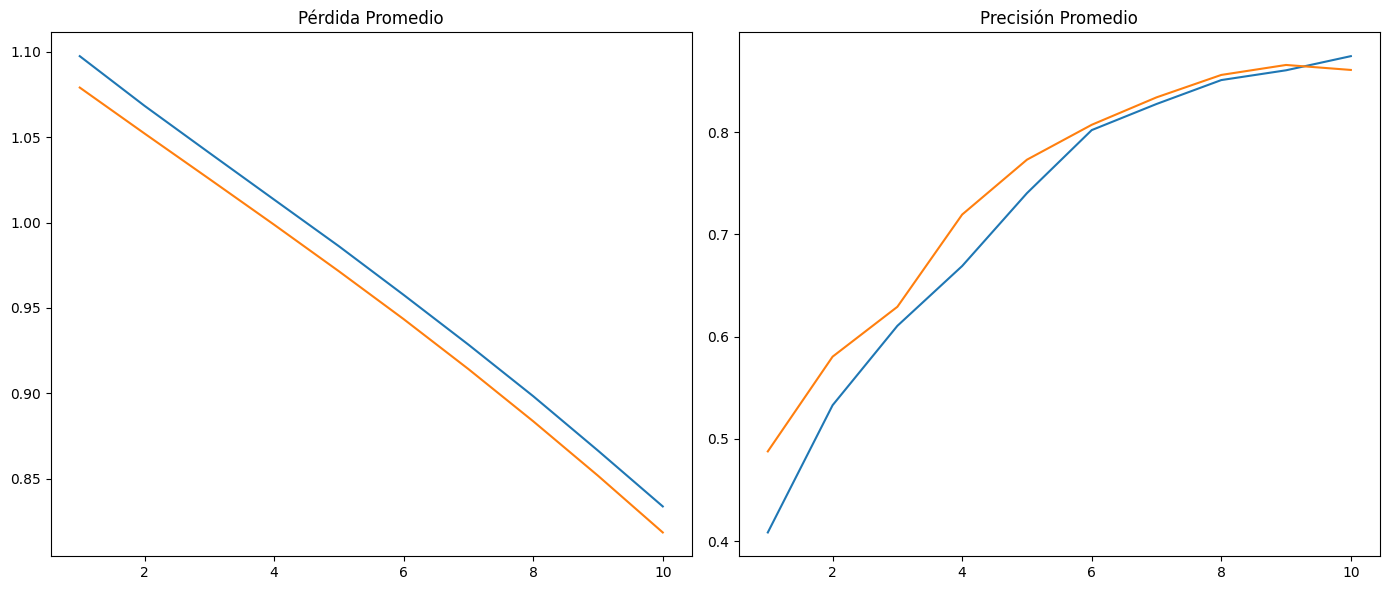

Grado 4: Pérdida Promedio = 0.7914, Precisión Promedio = 0.9133


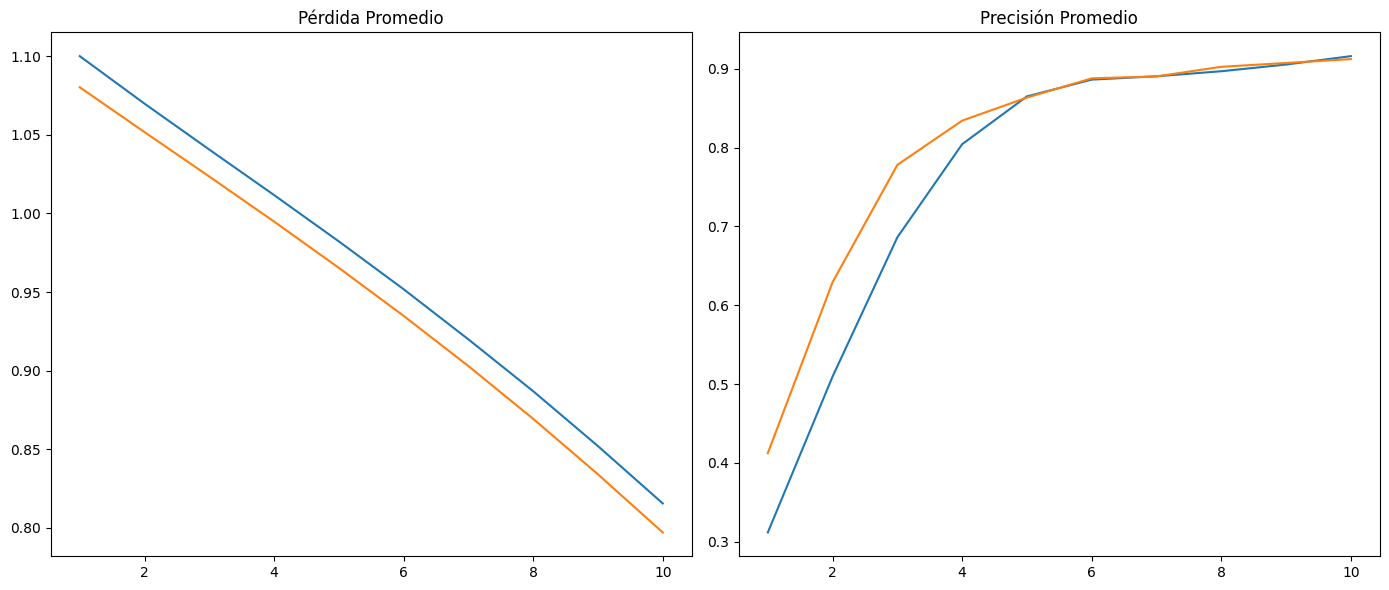

Grado 5: Pérdida Promedio = 0.7944, Precisión Promedio = 0.9000


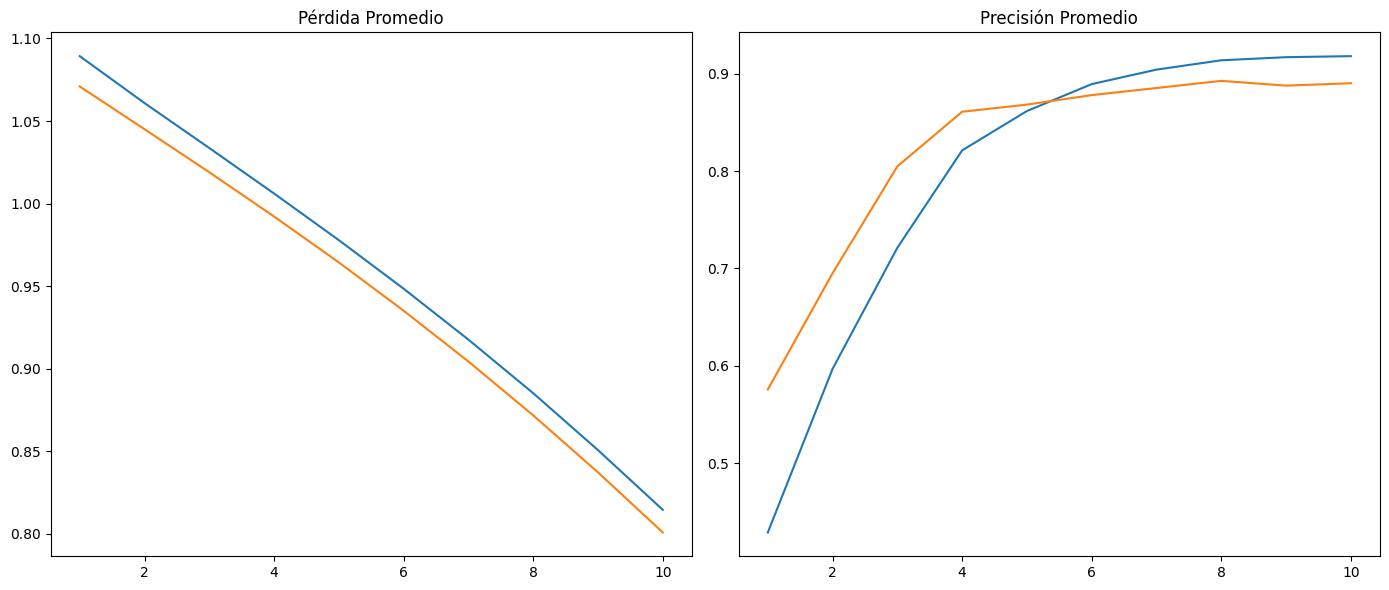

In [ ]:

# ===== RESULTADOS =====
def calculator(scores, times):
    loss = np.mean([s[0] for s in scores])
    acc = np.mean([s[1] for s in scores])
    t = np.mean(times)
    return loss, acc, t


print("\nRESULTADOS FINALES\n")

score_mean = {}

for deg in degrees:
    score_mean[deg] = calculator(scores[deg], times[deg])
    print(f"Grado {deg}: Pérdida Promedio = {score_mean[deg][0]:.4f}, Precisión Promedio = {score_mean[deg][1]:.4f}, Tiempo Promedio = {score_mean[deg][2]:.4f}")
    plot_cv_average_history(history[deg])